# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
# **2. Import Library**
import os

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split

# Model
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

from imblearn.over_sampling import SMOTE

# Warning
import warnings
warnings.filterwarnings('ignore')

# Setup visualization
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
#Type your code here

file_path = '../dataset/loan_data.csv'  # Update this with your actual file path
data = pd.read_csv(file_path)

display(data.head())

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [4]:
display(data.describe(include='all'))

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
count,45000.000000,45000,45000,4.500000e+04,45000.000000,45000,45000.000000,45000,45000.000000,45000.000000,45000.000000,45000.000000,45000,45000.000000
unique,NaN,2,5,NaN,NaN,4,NaN,6,NaN,NaN,NaN,NaN,2,NaN
top,NaN,male,Bachelor,NaN,NaN,RENT,NaN,EDUCATION,NaN,NaN,NaN,NaN,Yes,NaN
freq,NaN,24841,13399,NaN,NaN,23443,NaN,9153,NaN,NaN,NaN,NaN,22858,NaN
mean,27.764178,NaN,NaN,8.031905e+04,5.410333,NaN,9583.157556,NaN,11.006606,0.139725,5.867489,632.608756,NaN,0.222222
std,6.045108,NaN,NaN,8.042250e+04,6.063532,NaN,6314.886691,NaN,2.978808,0.087212,3.879702,50.435865,NaN,0.415744
min,20.000000,NaN,NaN,8.000000e+03,0.000000,NaN,500.000000,NaN,5.420000,0.000000,2.000000,390.000000,NaN,0.000000
25%,24.000000,NaN,NaN,4.720400e+04,1.000000,NaN,5000.000000,NaN,8.590000,0.070000,3.000000,601.000000,NaN,0.000000
50%,26.000000,NaN,NaN,6.704800e+04,4.000000,NaN,8000.000000,NaN,11.010000,0.120000,4.000000,640.000000,NaN,0.000000
75%,30.000000,NaN,NaN,9.578925e+04,8.000000,NaN,12237.250000,NaN,12.990000,0.190000,8.000000,670.000000,NaN,0.000000


In [5]:
print(f"Missing value per column:\n{data.isnull().sum()}")
print(f"\nDuplicate rows: {data.duplicated().sum()}")

Missing value per column:
person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

Duplicate rows: 0


Correlation matrix

In [11]:
# **4. EDA - Correlation Matrix**

# Buat copy dataframe untuk korelasi
df_corr = data.copy()

# Encode semua kolom categorical ke numerik
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

categorical_cols = ['person_gender', 'person_education', 'person_home_ownership', 
                    'loan_intent', 'previous_loan_defaults_on_file']

for col in categorical_cols:
    df_corr[col] = le.fit_transform(df_corr[col].astype(str))

# Hitung korelasi dengan target (loan_status)
correlation_with_target = df_corr.corr()['loan_status'].abs().sort_values(ascending=False)

print("\n" + "="*50)
print("KORELASI DENGAN LOAN STATUS")
print("="*50)
print("\nTop 10 Fitur yang Paling Berkorelasi dengan Loan Status:")
print(correlation_with_target[1:11])  # skip loan_status itself


KORELASI DENGAN LOAN STATUS

Top 10 Fitur yang Paling Berkorelasi dengan Loan Status:
previous_loan_defaults_on_file    0.543096
loan_percent_income               0.384880
loan_int_rate                     0.332005
person_home_ownership             0.233842
person_income                     0.135808
loan_amnt                         0.107714
loan_intent                       0.072158
person_age                        0.021476
person_emp_exp                    0.020481
cb_person_cred_hist_length        0.014851
Name: loan_status, dtype: float64


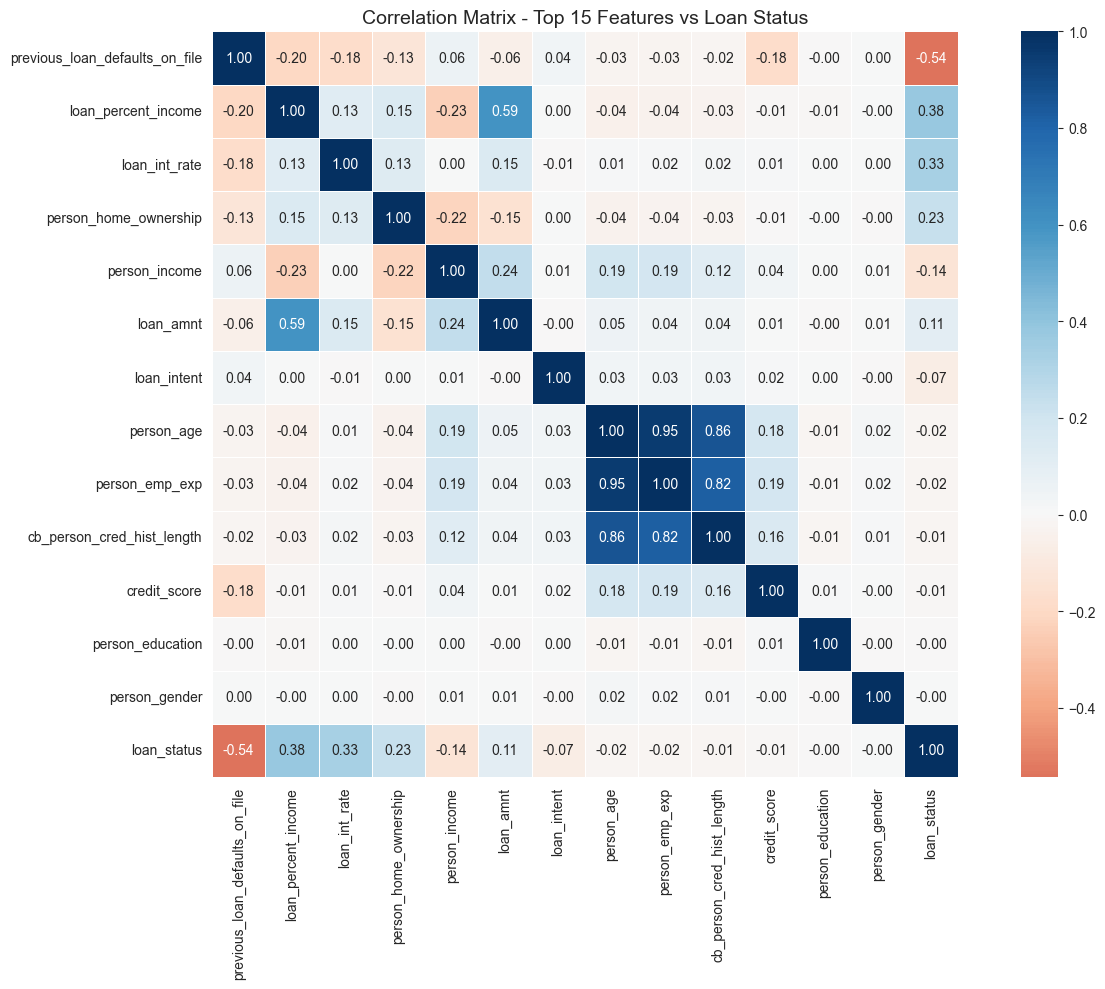

In [12]:
# Visualisasi Correlation Matrix (Heatmap)
plt.figure(figsize=(14, 10))

# Ambil top 15 fitur + target untuk heatmap
top_features = correlation_with_target[1:16].index.tolist()
top_features.append('loan_status')

# Plot heatmap
sns.heatmap(df_corr[top_features].corr(), 
            annot=True, 
            cmap='RdBu', 
            center=0,
            fmt='.2f',
            square=True,
            linewidths=0.5)
plt.title('Correlation Matrix - Top 15 Features vs Loan Status', fontsize=14)
plt.tight_layout()
plt.show()

Total Numerical Features: 8


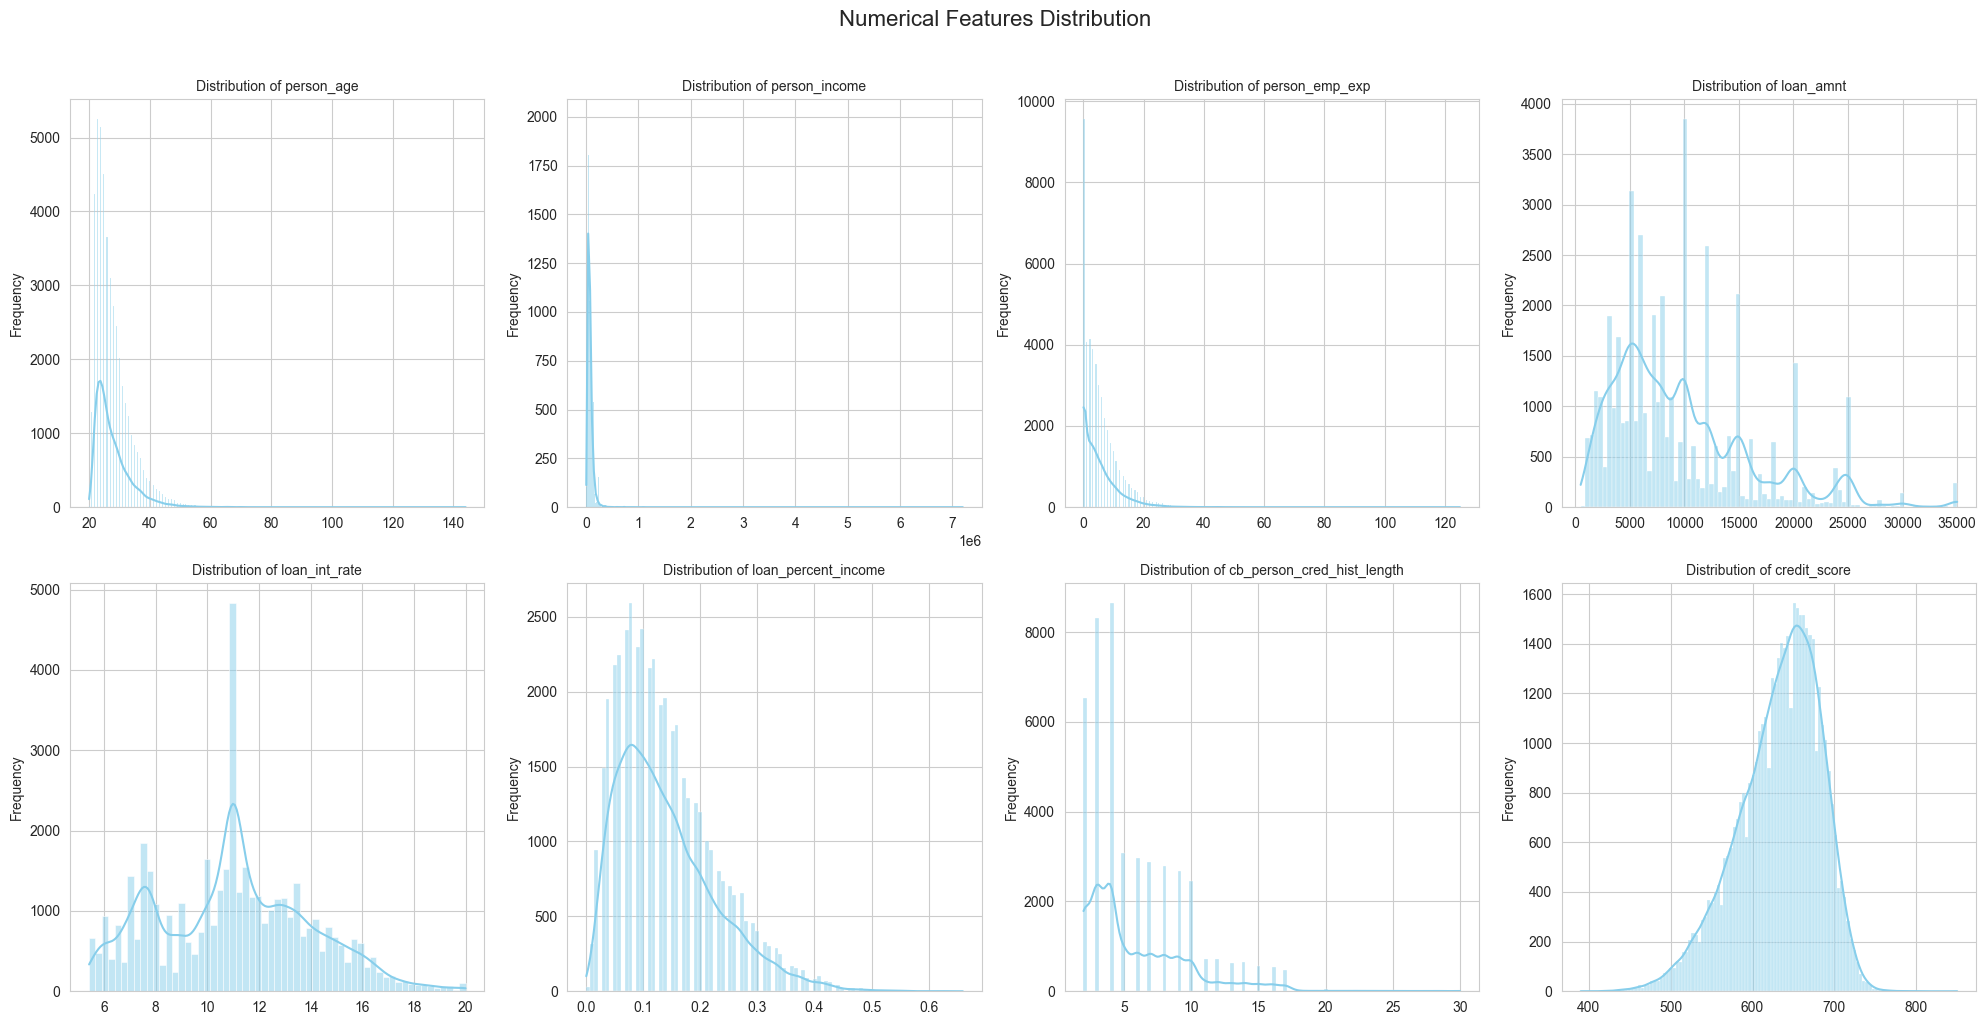

In [17]:
# **4. EDA - Distribusi Seluruh Fitur Numerik**

# Ambil semua fitur numerik (kecuali target 'loan_status')
num_features = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Hapus target dari list
num_features.remove('loan_status')
print(f"Total Numerical Features: {len(num_features)}")

# Setup grid
n_cols = 4 
n_rows = (len(num_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.histplot(data[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

# Hapus sumbu ekstra
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Numerical Features Distribution', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [18]:
# **5. Data Preprocessing - Remove Duplicate Rows**

print("PROSES REMOVE DUPLICATE ROWS")
print("="*50)
print(f"Shape awal dataset: {data.shape}")
print(f"Jumlah baris duplikat yang ditemukan: {data.duplicated().sum()}")

# Hapus baris duplikat
data = data.drop_duplicates(keep='first')

print(f"Shape dataset SETELAH data duplikat dihapus: {data.shape}")
print(f"Cek ulang duplikat: {data.duplicated().sum()}")

PROSES REMOVE DUPLICATE ROWS
Shape awal dataset: (45000, 14)
Jumlah baris duplikat yang ditemukan: 0
Shape dataset SETELAH data duplikat dihapus: (45000, 14)
Cek ulang duplikat: 0


In [23]:
# **5. Data Preprocessing untuk Loan Approval**

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
import os

# --- 2. Menangani Data Kosong (Missing Values) ---
print("2. MISSING VALUES HANDLING")
print("="*50)
print(f"Missing values sebelum handling: {data.isnull().sum().sum()}")

# Cek missing values per kolom
print("\nMissing values per kolom:")
print(data.isnull().sum()[data.isnull().sum() > 0])

# Isi missing values numerik dengan median
for col in data.select_dtypes(include=['float64', 'int64']).columns:
    if data[col].isnull().sum() > 0:
        data[col] = data[col].fillna(data[col].median())

# Isi missing values kategorikal dengan modus
for col in data.select_dtypes(include=['object']).columns:
    if data[col].isnull().sum() > 0:
        if data[col].mode().empty:
            data[col] = data[col].fillna(0)
        else:
            data[col] = data[col].fillna(data[col].mode()[0])

print(f"\nMissing values setelah handling: {data.isnull().sum().sum()}")
print()

# --- 3. Encoding Data Kategorikal ---
print("3. ENCODING DATA KATEGORIKAL")
print("="*50)
le = LabelEncoder()

# Identifikasi kolom kategorikal
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()

for col in categorical_cols:
    data[col] = le.fit_transform(data[col].astype(str))
    
print()

# --- 4. Normalisasi/Standarisasi Fitur ---
print("4. NORMALISASI FITUR")
print("="*50)

# Pisahkan fitur dan target dulu
target_col = 'loan_status'
X = data.drop(target_col, axis=1)
y = data[target_col]

# Scale fitur numerik dengan StandardScaler
scaler = StandardScaler()
num_cols = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
X[num_cols] = scaler.fit_transform(X[num_cols])

print(f"Fitur numerik yang di-scale ({len(num_cols)} fitur):")
print(f"   - {', '.join(num_cols)}")
print(f"   - Mean: {X[num_cols].mean().mean():.2f}")
print(f"   - Std: {X[num_cols].std().mean():.2f}")

# Gabungkan kembali X dan y
data_processed = X.copy()
data_processed[target_col] = y

print()

# --- 5. Menyimpan Data Hasil Preprocessing ---
output_dir = './loan_preprocessing'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'loan_processed.csv')

data_processed.to_csv(output_path, index=False)

print("="*60)
print("✅ PREPROCESSING SELESAI!")
print("="*60)
print(f"📁 File saved: {output_path}")
print(f"📊 Shape akhir dataset: {data_processed.shape}")
print(f"\n📈 Target distribution:")
print(f"   - Approved (1): {(data_processed[target_col]==1).sum():,}")
print(f"   - Not Approved (0): {(data_processed[target_col]==0).sum():,}")
print(f"\n📦 Scaler disimpan di: {output_dir}")

2. MISSING VALUES HANDLING
Missing values sebelum handling: 0

Missing values per kolom:
Series([], dtype: int64)

Missing values setelah handling: 0

3. ENCODING DATA KATEGORIKAL

4. NORMALISASI FITUR
Fitur numerik yang di-scale (13 fitur):
   - person_age, person_gender, person_education, person_income, person_emp_exp, person_home_ownership, loan_amnt, loan_intent, loan_int_rate, loan_percent_income, cb_person_cred_hist_length, credit_score, previous_loan_defaults_on_file
   - Mean: -0.00
   - Std: 1.00

✅ PREPROCESSING SELESAI!
📁 File saved: ./loan_preprocessing\loan_processed.csv
📊 Shape akhir dataset: (45000, 14)

📈 Target distribution:
   - Approved (1): 10,000
   - Not Approved (0): 35,000

📦 Scaler disimpan di: ./loan_preprocessing
